# LLM score comparison

In [18]:
import pandas as pd

In [19]:
scores_llama = pd.read_csv("data/EuroParl/scored_llama/scored_data_0_500.csv", sep=';', encoding="utf-8-sig")
scores_gpt = pd.read_csv("data/EuroParl/scored_gpt/scored_data_gpt_first1000.csv", sep=';', encoding="utf-8-sig")
scores_gpt = scores_gpt.iloc[:500]
scores_llama['score_diff'] = scores_llama['score'] - scores_gpt['score'].values
scores_llama.sort_values(by=['score_diff']).to_csv(
                f"data/EuroParl/scored_diff.csv",
                sep=";",
                index=False,
                encoding="utf-8-sig"
            )

,en,score,reason,EU Party,score_diff
140,"According to current estimates, it will be aro...",0.0,The text only provides a statistic without exp...,EPP-ED,-0.92
469,"If we continue to talk in this manner, in a we...",0.1,The speech expresses a prediction of consequen...,PES,-0.80
455,Iran’s foreign policy objective is to become t...,0.1,The statement describes Iran's foreign policy ...,EPP-ED,-0.80
308,I hope that the reliance on mutual trust of th...,0.1,The speech expresses a vague hope for mutual t...,PES,-0.80
258,Do you think that the implementation or the ad...,0.1,The speech asks questions about taxation and s...,EPP-ED,-0.80
...,...,...,...,...,...
353,We can only hope that the Czech presidency wil...,0.9,Strong expression of skepticism towards the Eu...,DEM,0.80
406,It accepts and welcomes all the reactionary pr...,0.9,Strong expression of an ideological position c...,NGL,0.80
287,This sector therefore requires wide-ranging re...,0.9,The speech advocates for wide-ranging regulati...,EPP-ED,0.90
113,"Yet, the Irish Government has recently cut its...",0.9,The speech strongly criticizes the Irish Gover...,PES,0.90


In [20]:
import numpy as np

mse = np.median(
    (scores_gpt["score"].values - scores_llama["score"].values)
)

print("Mean Squared Difference:", mse)

Mean Squared Difference: 0.09999999999999998


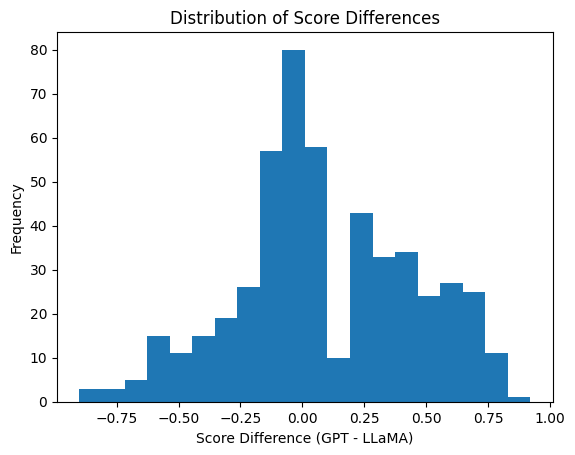

In [21]:
diff = scores_gpt["score"] - scores_llama["score"]
import matplotlib.pyplot as plt

plt.hist(diff, bins=20)
plt.xlabel("Score Difference (GPT - LLaMA)")
plt.ylabel("Frequency")
plt.title("Distribution of Score Differences")
plt.show()